# What complex rules add

In [1]:
import os
import sys
from dataclasses import replace

sys.path[:0] = [os.path.abspath("scripts"), os.path.abspath(".."), os.path.abspath("../differential_rules/scripts")]
import complex_investigation as ci
import complex_investigation_vis as vis
import complex_hypotheses as hypotheses
from IPython.display import display

In [2]:
CONFIG = ci.Config(
    max_items=4, support=0.01, expected_support=0.01, confidence=0.5,
    min_cells=20, min_fovs=5, min_patients=3, min_group_fovs=10,
    visible_gap=0.15, top_n=8, permutations=4999,
    score=os.environ.get("SCORE_COLUMN", "Clinical score"),
)
PREFIX = "overview_" + ("clin" if CONFIG.score.startswith("Clinical") else "path")

[C] marks the center; every other item is a neighbor. Rules retain their stored mining FDR and classification. Attraction requires the displayed observed support and confidence; avoidance uses expected support = Support − Leverage, including Lift = 0. Eligibility requires every named type in the FOV.

Stage tests reuse the differential permutation methods (fixed seed 0): FOV occurrence, biopsy mean, and patient mean of biopsy means. Cross-stage patients are omitted only from unpaired patient tests, never from plots. BH correction covers both organs, both rule states and all three contrasts plus the ordered trend within each analysis and unit. These exploratory screens are not independent validation. Patient FDR is evidence, not a mandatory display gate.

In [3]:
cells, metadata, rules = ci.load(CONFIG)

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv + results_CN_complex.csv
{'max_items': 4, 'min_cells': 20, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
690,345 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None

In [4]:
analysis = ci.analyse(rules, cells, metadata, CONFIG)
GAINS = ci.gain_candidates(analysis, rules, metadata)
RECURRENT = ci.candidates(analysis["counts"], analysis["tests"], CONFIG, purpose="recurrence")
# A rule already shown for its gain is not repeated in the recurrence list.
RECURRENT = RECURRENT[~RECURRENT.set_index(["organ", "rule", "kind"]).index.isin(
    GAINS.set_index(["organ", "rule", "kind"]).index)].reset_index(drop=True)
SPECS = ci.pd.concat([GAINS, RECURRENT]).reset_index(drop=True)
ci.save_tables(analysis, SPECS, PREFIX)
display(GAINS)
display(RECURRENT)

,organ,rule,kind,gain,matched_fovs,patients,stream,contrast
1141,Colon,Endothelial + Epithelial -> Goblet + SMV,attracts,0.965169,9,8,measured gain,Control–Severe
6129,Duodenum,CD8T + Epithelial -> Goblet + Plasma,attracts,0.852403,5,4,measured gain,Control–Severe
2785,Colon,Macrophage + Plasma -> Muscle,avoids,0.495639,7,5,measured gain,Control–Severe
11463,Duodenum,Macrophage + Plasma -> Muscle,avoids,0.409767,7,6,measured gain,Control–Severe


,organ,rule,kind,gap,contrast,patient_fdr,hits,patients,eligible,share,stream
0,Colon,Goblet -> CD8T + Macrophage,avoids,0.414545,Control–Mild,0.674259,62,19,77,0.805195,recurrence
1,Colon,Goblet -> CD4T + Macrophage,avoids,0.270270,Control–Severe,0.674259,56,16,71,0.788732,recurrence
2,Duodenum,Goblet -> Fibroblast + Macrophage,avoids,0.049275,Control–Severe,0.956526,103,40,136,0.757353,recurrence
3,Duodenum,Goblet -> CD4T + Macrophage,avoids,0.333333,Control–Severe,0.703703,75,32,126,0.595238,recurrence
4,Colon,Epithelial + Neuron -> Fibroblast + Goblet,attracts,0.336207,Mild–Severe,0.897029,27,13,55,0.490909,recurrence
5,Colon,Epithelial + Plasma -> Goblet + Macrophage,attracts,0.105455,Control–Severe,1.000000,24,10,51,0.470588,recurrence
6,Duodenum,Epithelial + Plasma_CD38 -> Goblet + Plasma,attracts,0.079960,Mild–Severe,0.784913,30,19,98,0.306122,recurrence
7,Duodenum,Endocrine + Fibroblast -> Epithelial + Macrophage,attracts,0.000000,none,1.000000,11,7,37,0.297297,recurrence


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_attracts_classes.pdf


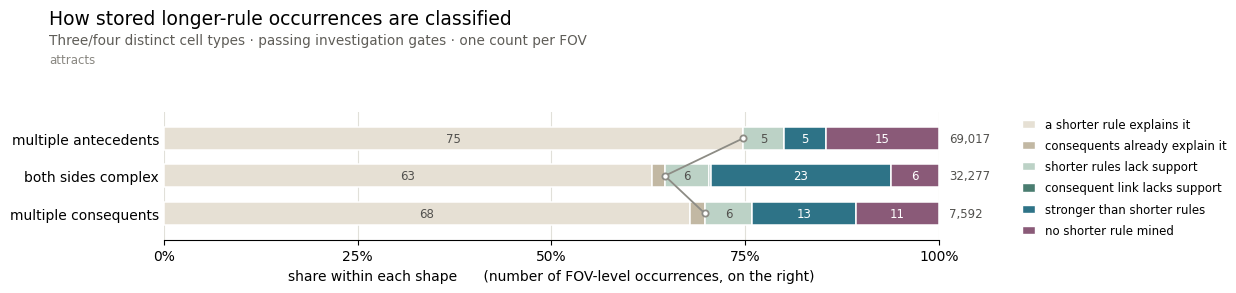

In [5]:
vis.show_classes("attracts", rules, CONFIG, PREFIX)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_avoids_classes.pdf


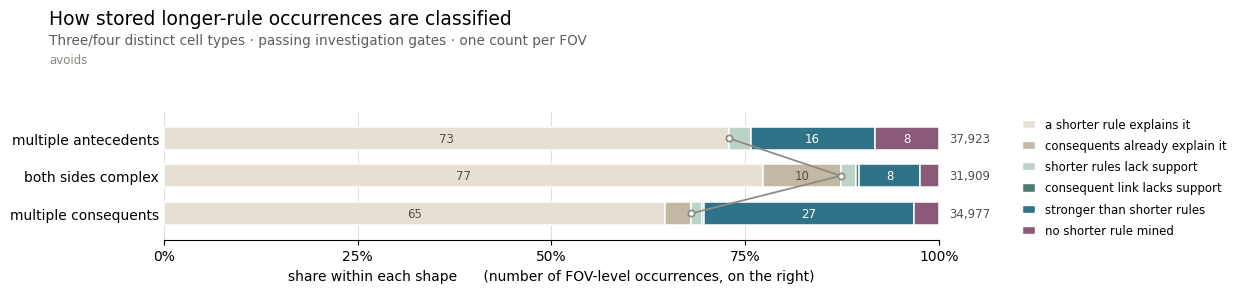

In [6]:
vis.show_classes("avoids", rules, CONFIG, PREFIX)

Each cell shows one automatically selected rule. Blue/red prevalence and Lift use eligible FOVs; the bottom bar also shows the ineligible fields. A missing shorter rule is not assigned an artificial gain.

In [7]:
def show_gain(index):
    vis.show_selected(index, GAINS, analysis, rules, cells, metadata, PREFIX,
                      parents=True, pooled=True)


def show_recurrent(index):
    vis.show_selected(index, RECURRENT, analysis, rules, cells, metadata, PREFIX,
                      parents=True, pooled=True)

## 1. Rules that beat a shorter rule

Chosen by the median same-field improvement over the strongest shorter rule measured in that same field: one rule per organ and direction. Every rule here has a shorter rule to compare against, so the parent panels are filled.

**[0] Colon · Endothelial + Epithelial -> Goblet + SMV**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,9,34,97,8,16
1,All,avoids,0,34,97,0,16
2,Control,attracts,2,15,25,2,4
3,Control,avoids,0,15,25,0,4
4,Mild,attracts,1,3,18,1,2
5,Mild,avoids,0,3,18,0,2
6,Severe,attracts,6,16,54,5,10
7,Severe,avoids,0,16,54,0,10


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_276326dad7_parent_vs_complex.pdf


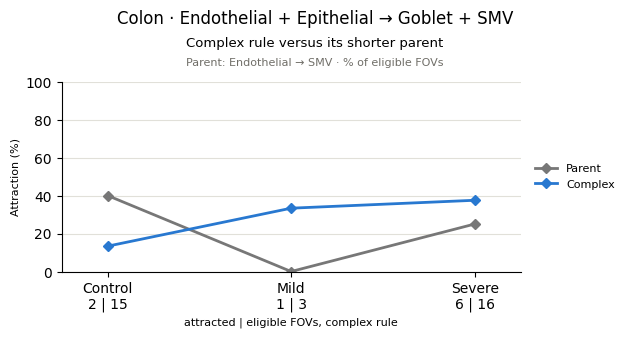

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_276326dad7_summary.pdf


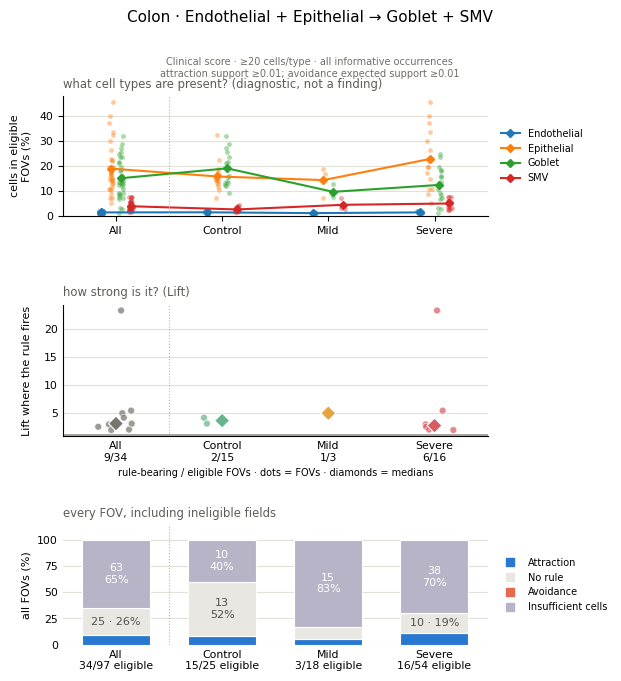

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_276326dad7_parents.pdf


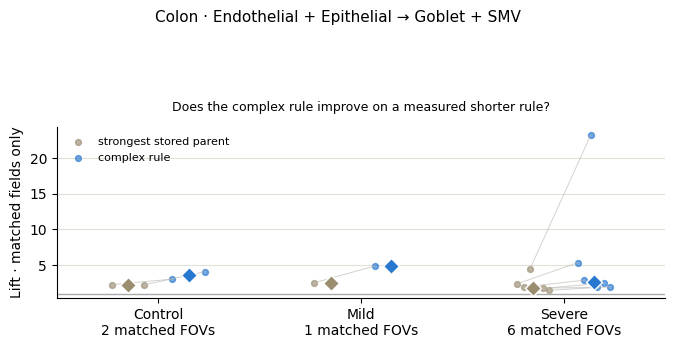

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,2,3.551969,2.229348,1
Severe,6,2.664612,1.830009,4
Mild,1,4.881623,2.511109,1


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_276326dad7_fovs_attraction.pdf


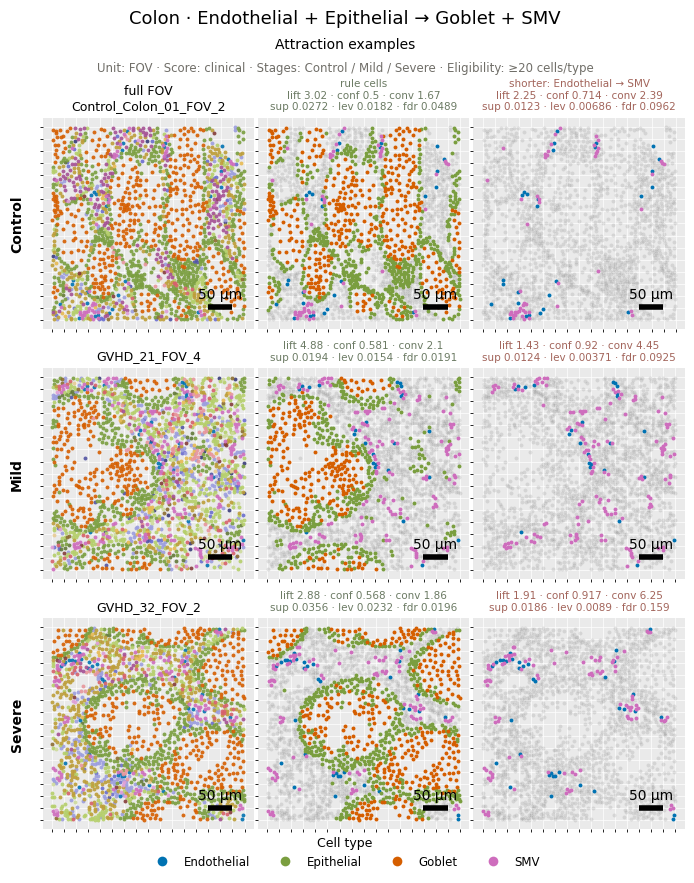

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_276326dad7_fovs_no_rule.pdf


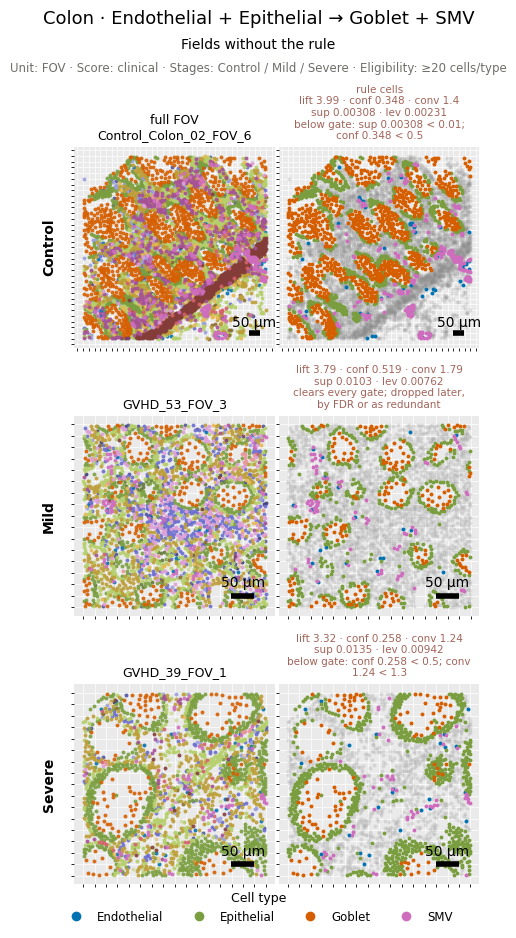

In [8]:
show_gain(0)

**[1] Duodenum · CD8T + Epithelial -> Goblet + Plasma**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,5,79,170,4,31
1,All,avoids,0,79,170,0,31
2,Control,attracts,0,28,31,0,10
3,Control,avoids,0,28,31,0,10
4,Mild,attracts,4,35,98,3,15
5,Mild,avoids,0,35,98,0,15
6,Severe,attracts,1,16,41,1,6
7,Severe,avoids,0,16,41,0,6


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_75f281cb73_parent_vs_complex.pdf


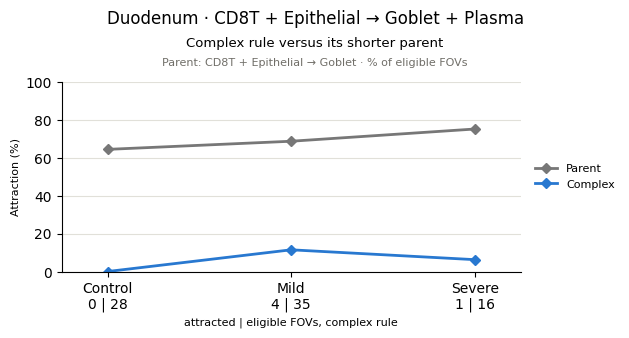

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_75f281cb73_summary.pdf


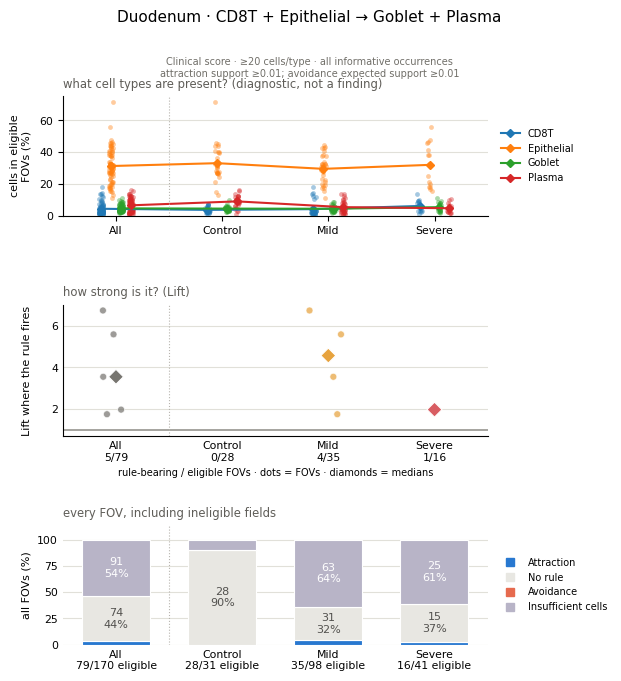

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_75f281cb73_parents.pdf


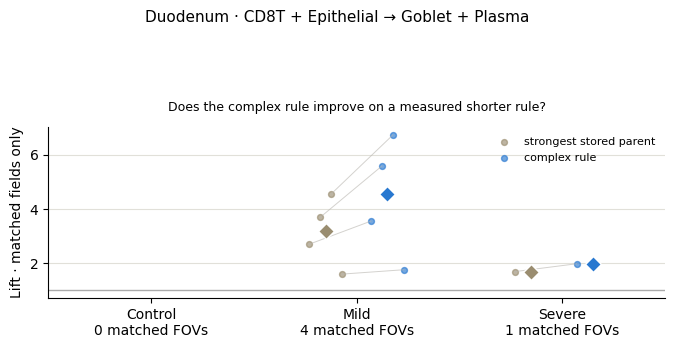

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Mild,4,4.571213,3.198877,4
Severe,1,1.979523,1.690706,1


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_75f281cb73_fovs_attraction.pdf


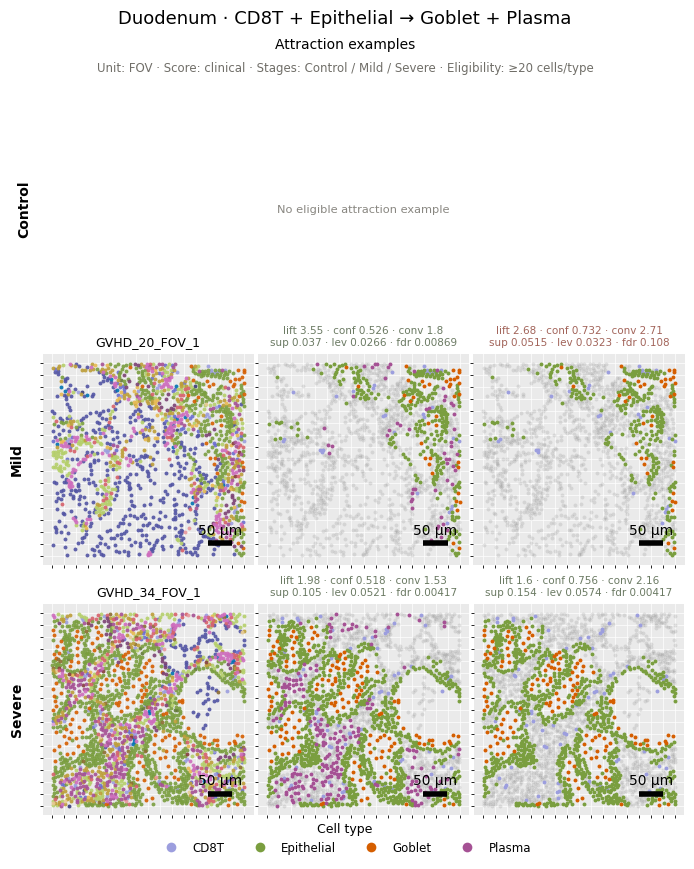

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_75f281cb73_fovs_no_rule.pdf


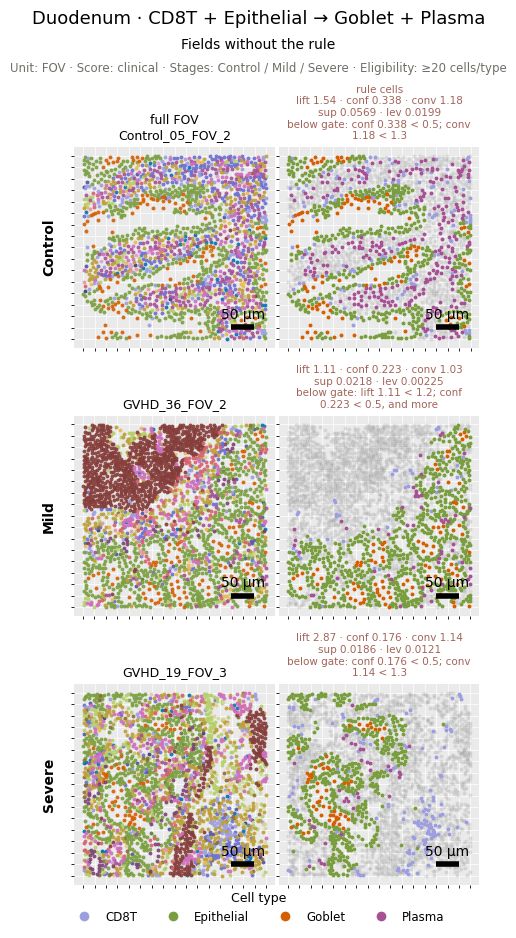

In [9]:
show_gain(1)

**[2] Colon · Macrophage + Plasma -> Muscle**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,30,97,0,10
1,All,avoids,11,30,97,7,10
2,Control,attracts,0,20,25,0,4
3,Control,avoids,7,20,25,4,4
4,Mild,attracts,0,1,18,0,1
5,Mild,avoids,1,1,18,1,1
6,Severe,attracts,0,9,54,0,5
7,Severe,avoids,3,9,54,2,5


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_48a16be7e9_parent_vs_complex.pdf


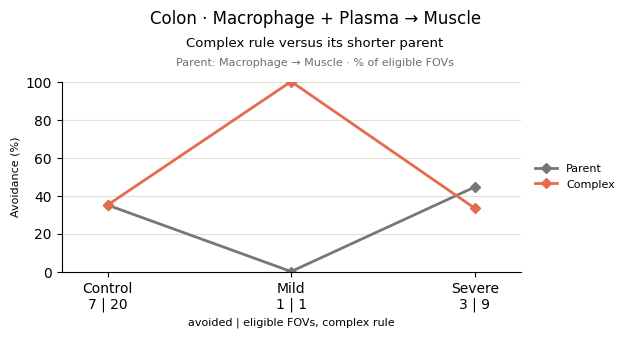

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_48a16be7e9_summary.pdf


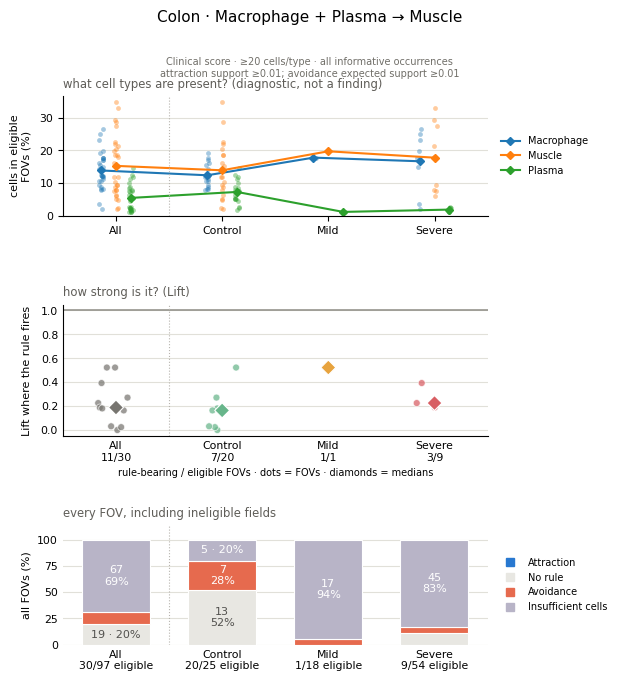

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_48a16be7e9_parents.pdf


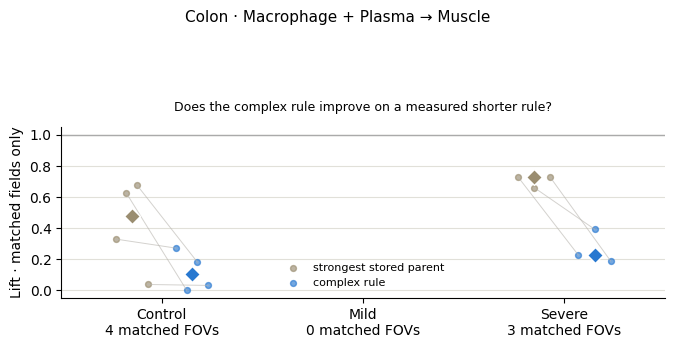

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,4,0.106143,0.477878,4
Severe,3,0.225744,0.727212,3


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_48a16be7e9_fovs_avoidance.pdf


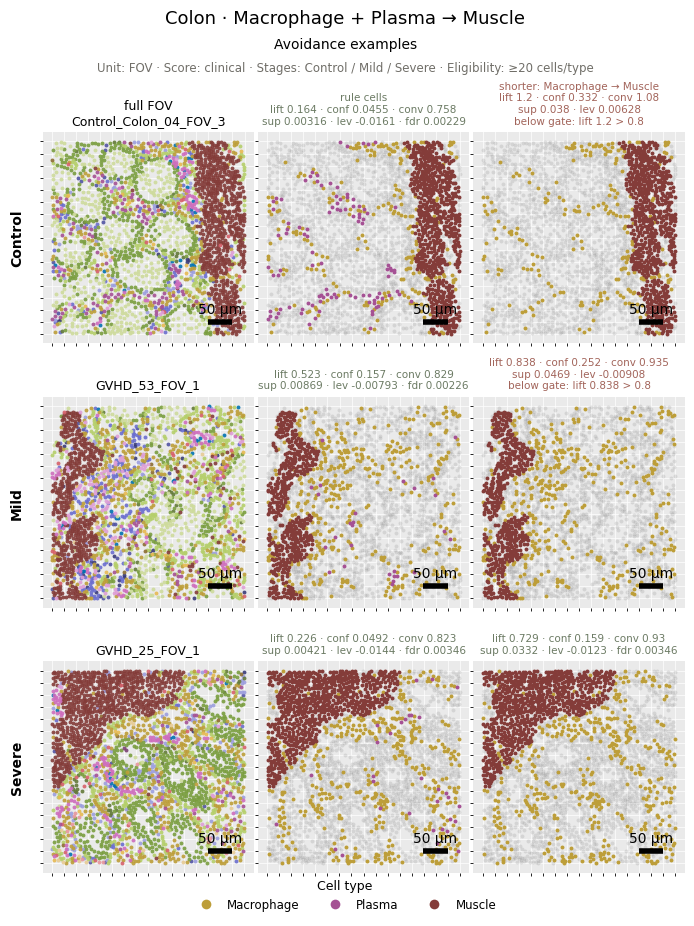

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_48a16be7e9_fovs_no_rule.pdf


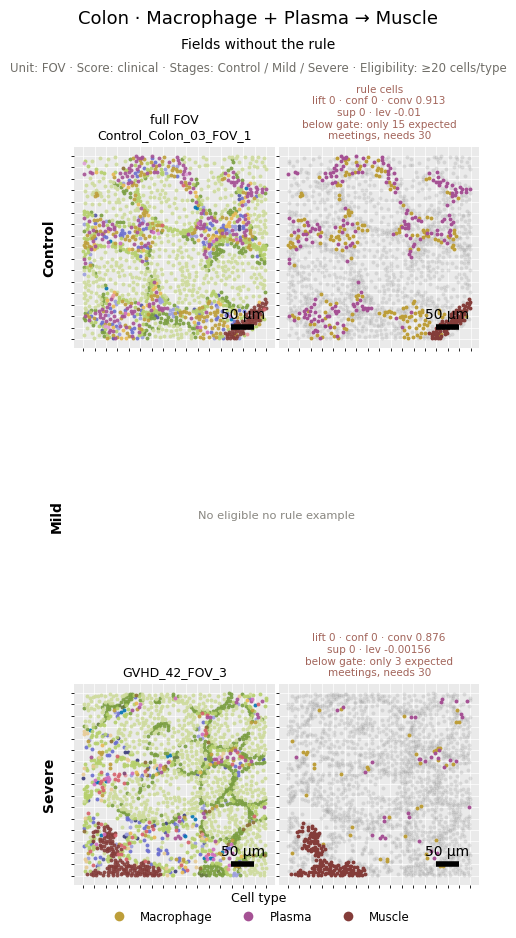

In [10]:
show_gain(2)

**[3] Duodenum · Macrophage + Plasma -> Muscle**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,91,170,0,40
1,All,avoids,9,91,170,7,40
2,Control,attracts,0,17,31,0,8
3,Control,avoids,0,17,31,0,8
4,Mild,attracts,0,54,98,0,23
5,Mild,avoids,3,54,98,3,23
6,Severe,attracts,0,20,41,0,9
7,Severe,avoids,6,20,41,4,9


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_8dd10b5745_parent_vs_complex.pdf


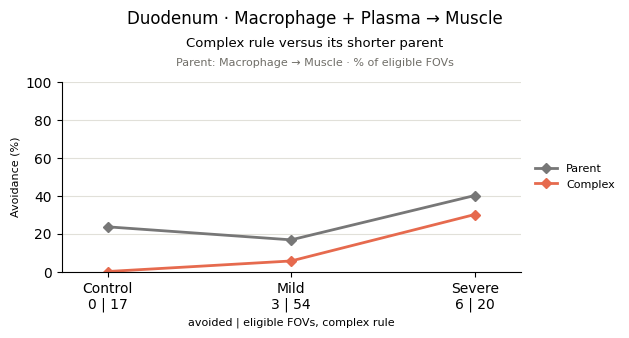

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_8dd10b5745_summary.pdf


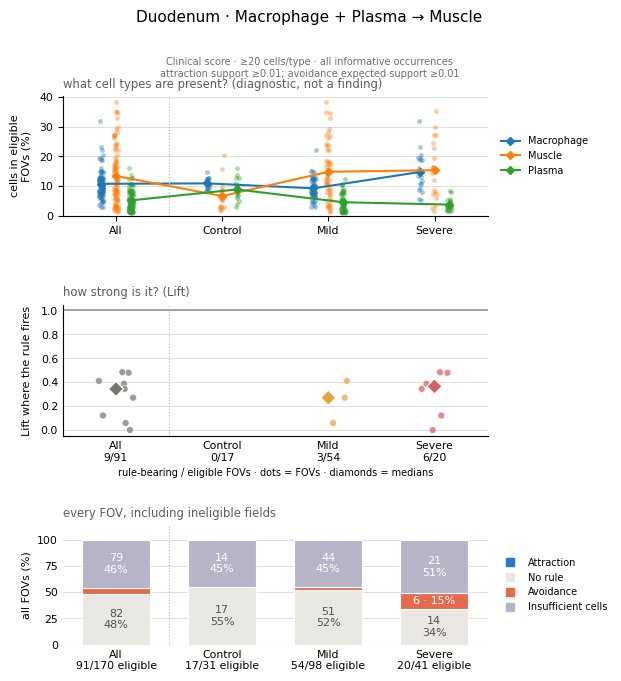

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_8dd10b5745_parents.pdf


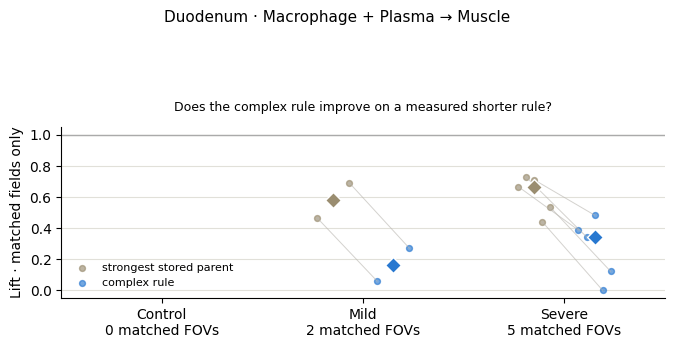

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Mild,2,0.164468,0.580908,2
Severe,5,0.343857,0.668059,5


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_8dd10b5745_fovs_avoidance.pdf


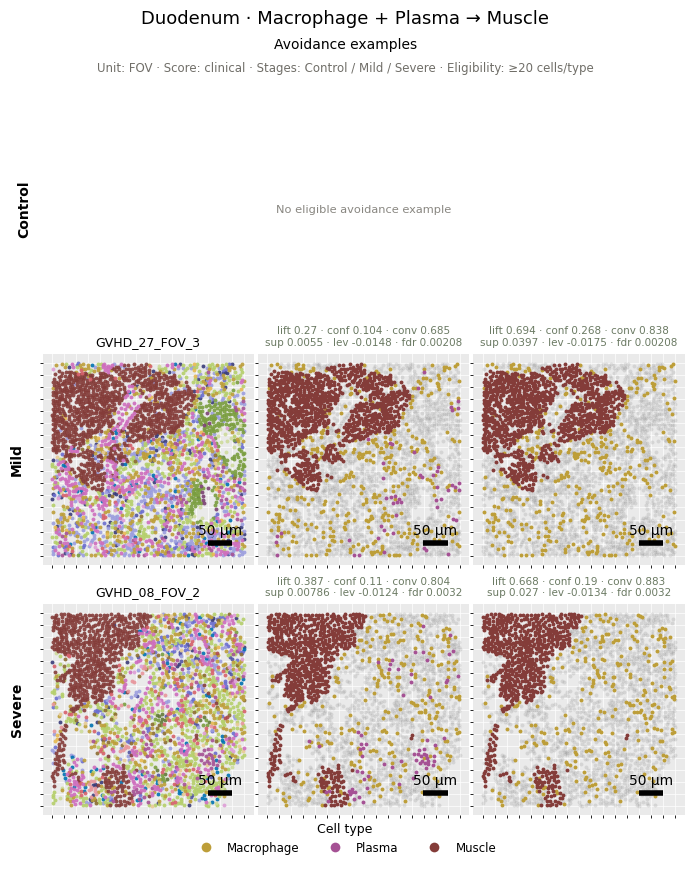

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_8dd10b5745_fovs_no_rule.pdf


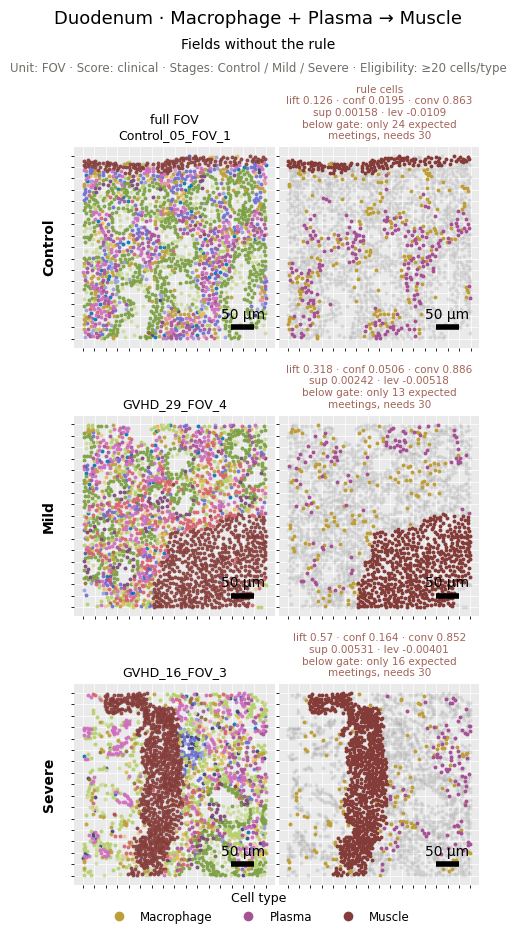

In [11]:
show_gain(3)

## 2. Rules that recur across fields

Chosen by how often the rule occurs, not by any comparison: at least 10 rule-bearing fields, 5 patients, and a tenth of the eligible fields. No shorter rule is involved, so these often have no parent panel. Add or remove a cell below to show more or fewer.

**[0] Colon · Goblet -> CD8T + Macrophage**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,77,97,0,19
1,All,avoids,62,77,97,19,19
2,Control,attracts,0,25,25,0,4
3,Control,avoids,24,25,25,4,4
4,Mild,attracts,0,11,18,0,3
5,Mild,avoids,6,11,18,3,3
6,Severe,attracts,0,41,54,0,12
7,Severe,avoids,32,41,54,12,12


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_3e21af8591_parent_vs_complex.pdf


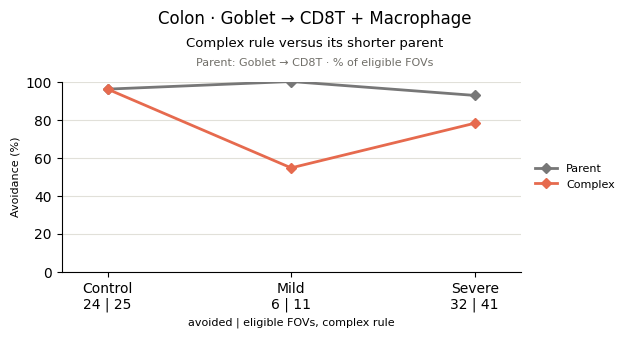

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_3e21af8591_summary.pdf


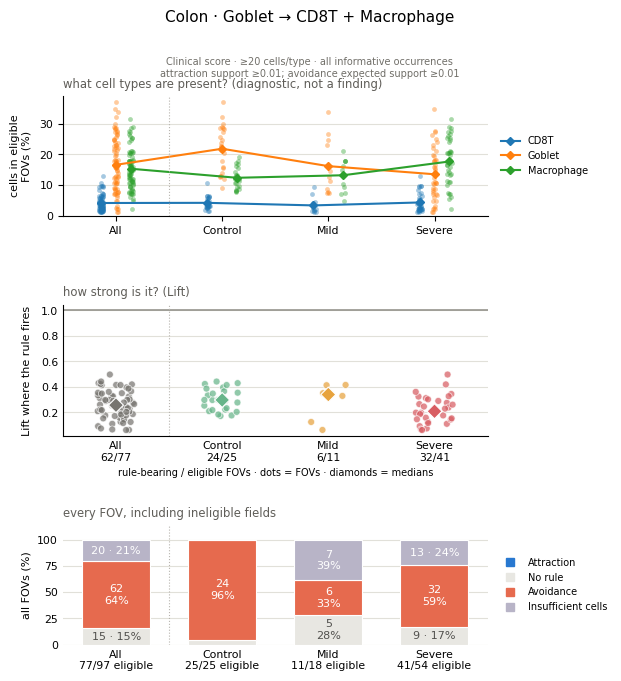

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_3e21af8591_parents.pdf


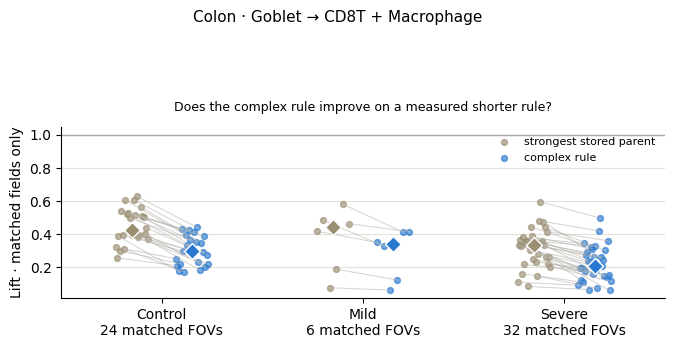

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,24,0.297258,0.427931,24
Severe,32,0.208416,0.336724,32
Mild,6,0.339990,0.440721,6


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_3e21af8591_fovs_avoidance.pdf


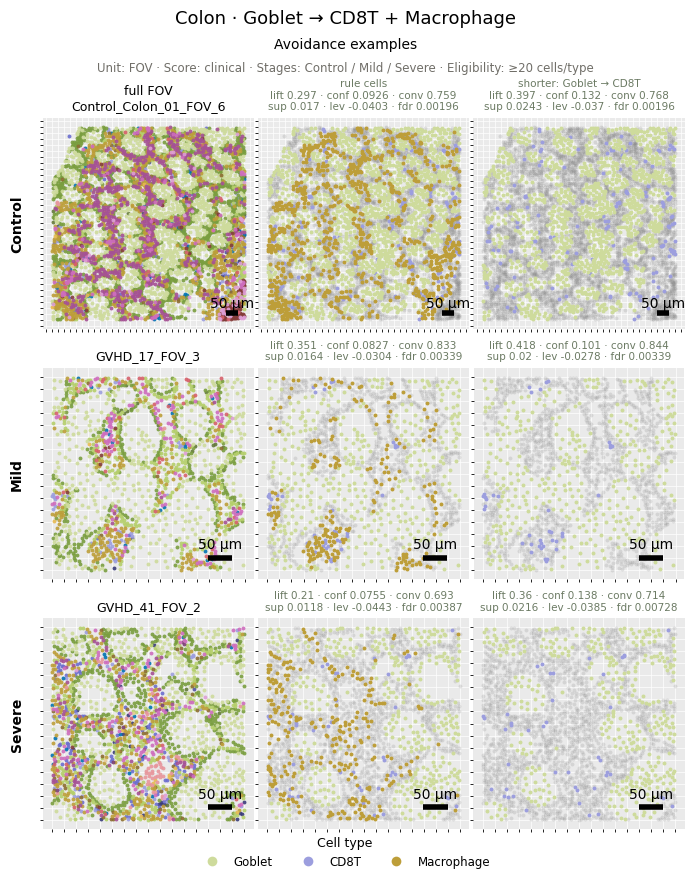

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_3e21af8591_fovs_no_rule.pdf


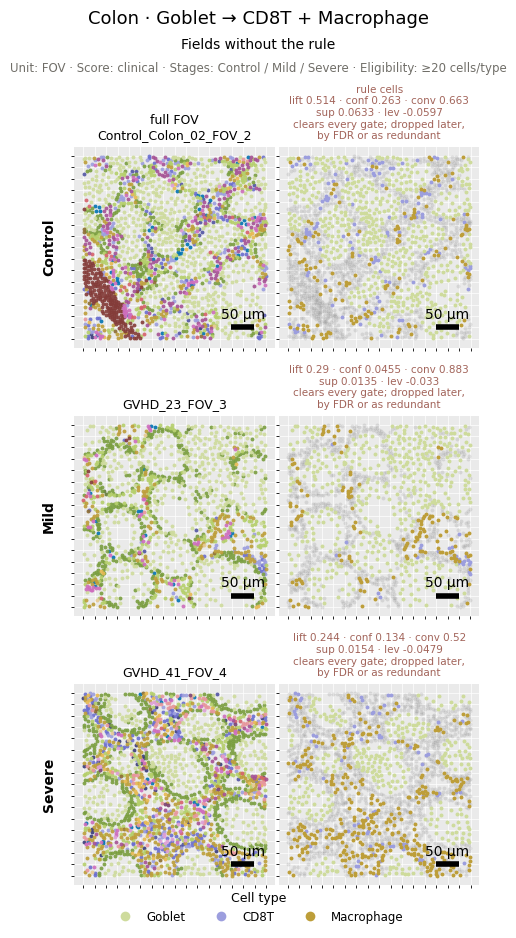

In [12]:
show_recurrent(0)

**[1] Colon · Goblet -> CD4T + Macrophage**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,71,97,0,18
1,All,avoids,56,71,97,16,18
2,Control,attracts,0,25,25,0,4
3,Control,avoids,25,25,25,4,4
4,Mild,attracts,0,9,18,0,3
5,Mild,avoids,4,9,18,2,3
6,Severe,attracts,0,37,54,0,11
7,Severe,avoids,27,37,54,10,11


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_5cb52cff60_parent_vs_complex.pdf


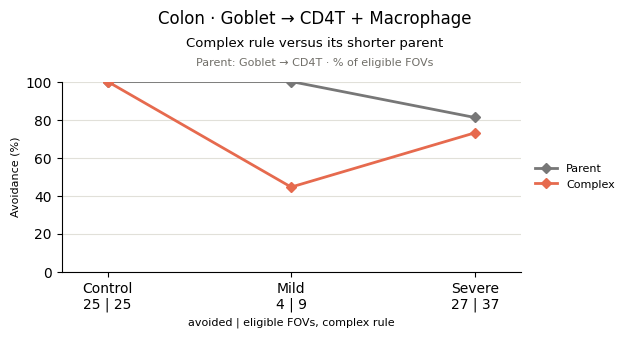

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_5cb52cff60_summary.pdf


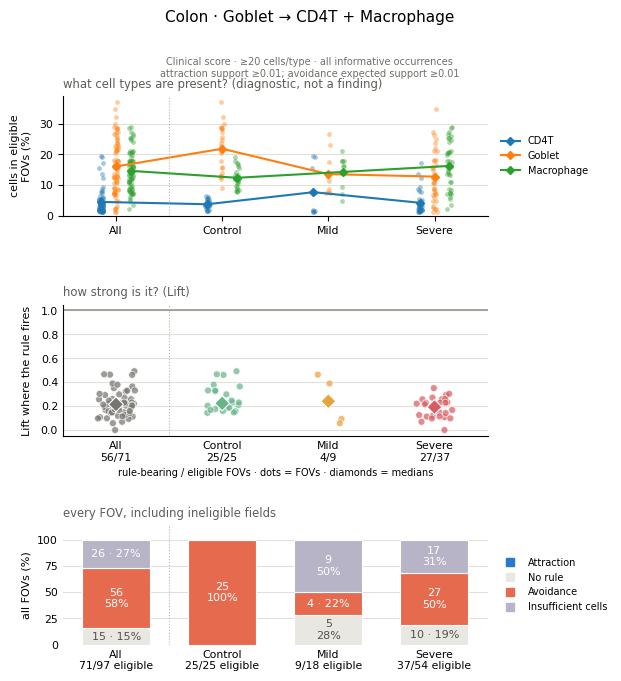

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_5cb52cff60_parents.pdf


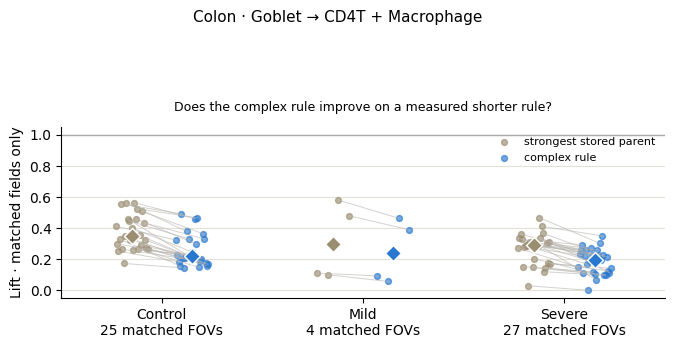

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,25,0.223229,0.346425,25
Severe,27,0.192612,0.290370,27
Mild,4,0.241098,0.295333,4


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_5cb52cff60_fovs_avoidance.pdf


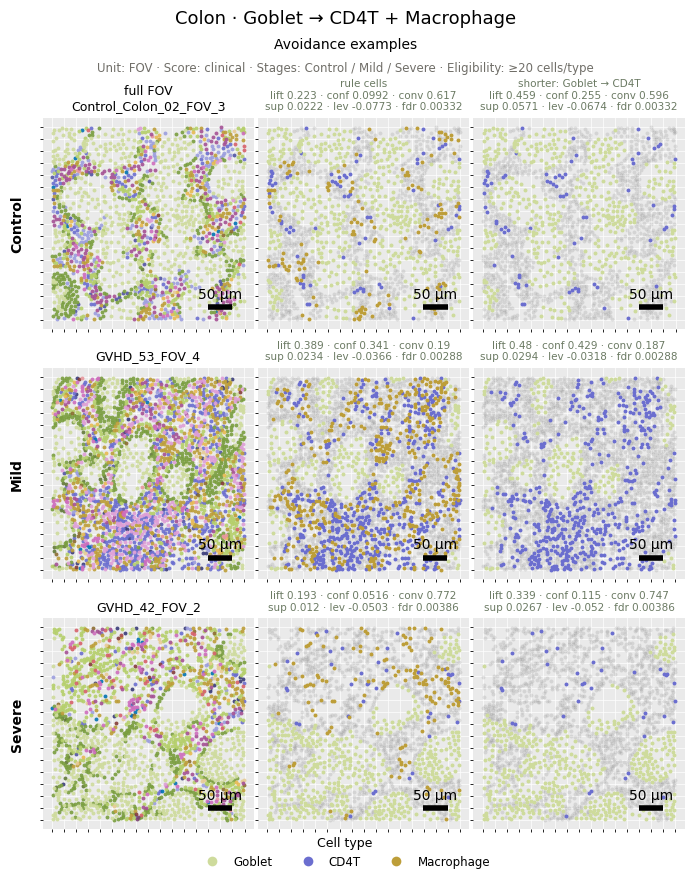

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Colon_5cb52cff60_fovs_no_rule.pdf


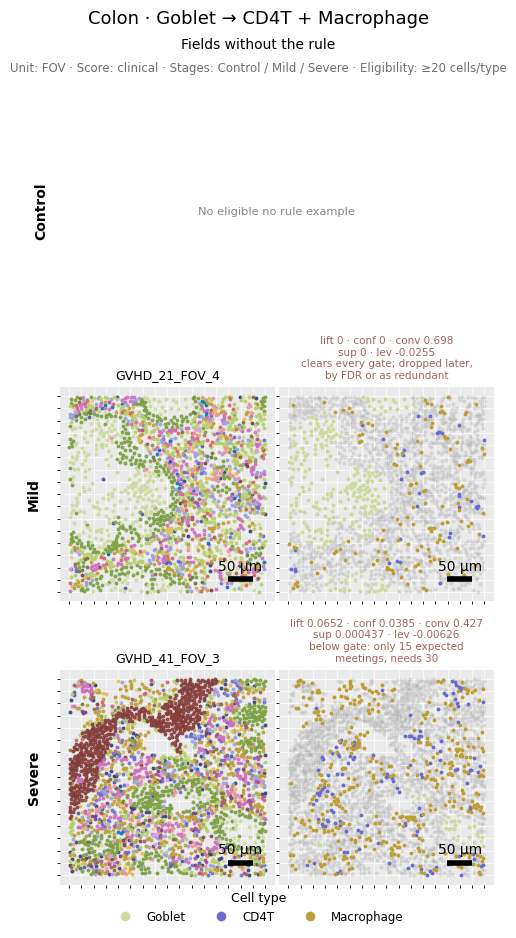

In [13]:
show_recurrent(1)

**[2] Duodenum · Goblet -> Fibroblast + Macrophage**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,136,170,0,43
1,All,avoids,103,136,170,40,43
2,Control,attracts,0,30,31,0,10
3,Control,avoids,22,30,31,10,10
4,Mild,attracts,0,83,98,0,26
5,Mild,avoids,63,83,98,23,26
6,Severe,attracts,0,23,41,0,7
7,Severe,avoids,18,23,41,7,7


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_539c9a09e7_parent_vs_complex.pdf


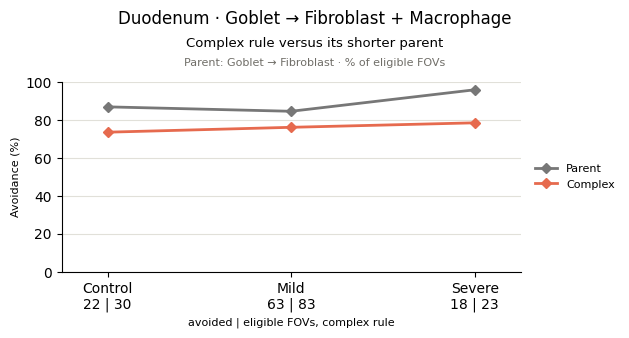

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_539c9a09e7_summary.pdf


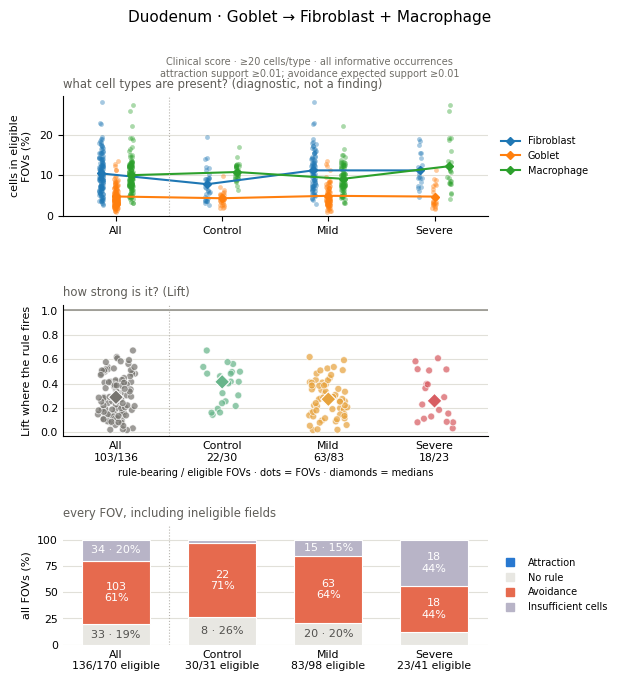

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_539c9a09e7_parents.pdf


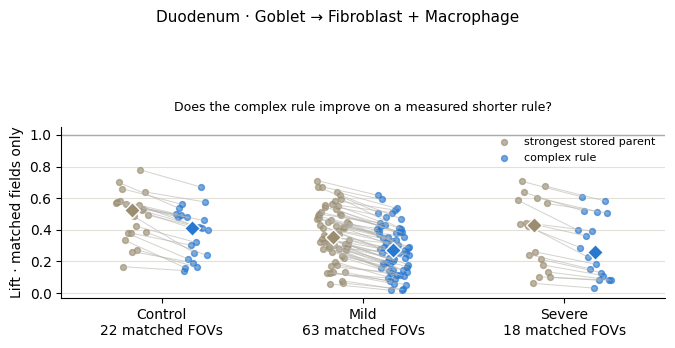

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,22,0.413617,0.527185,22
Mild,63,0.271304,0.356708,63
Severe,18,0.257628,0.432774,18


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_539c9a09e7_fovs_avoidance.pdf


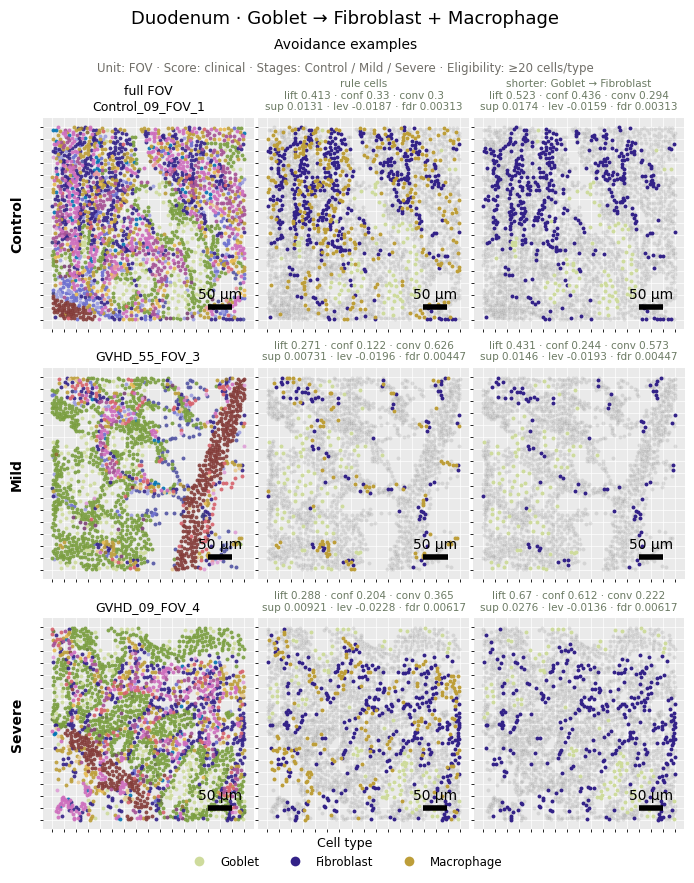

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\overview_clin_Duodenum_539c9a09e7_fovs_no_rule.pdf


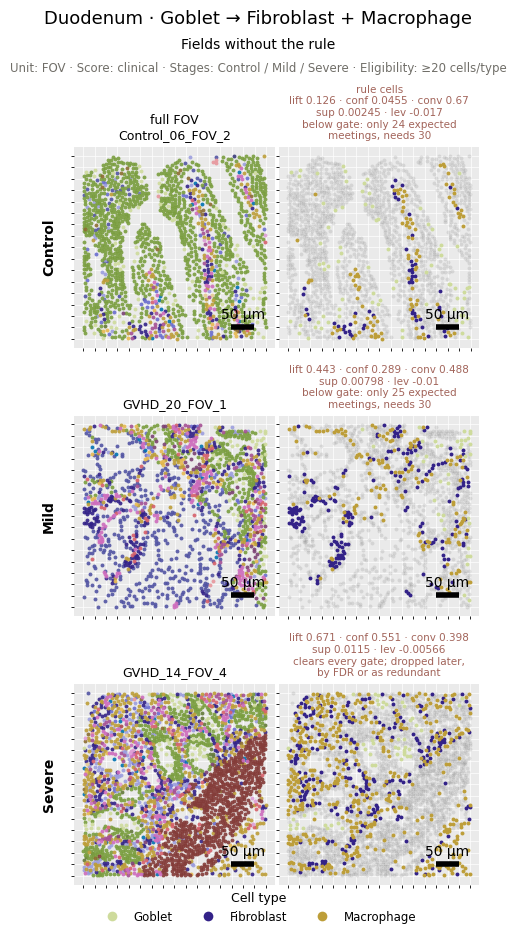

In [14]:
show_recurrent(2)

All stage-test results and denominators are saved beside the figures as CSV files. Change the configuration and rerun all cells; indexed cells outside the selected table safely print a note.